In [18]:
import pandas as pd
import os
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import shap
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from sklearn.ensemble import IsolationForest

In [19]:
BASE_PATH = '/kaggle/input/datasets/andreeabrleanu/yahoo-dataset'

dfs = {}

for file in [
    'train.csv',
    'ham_test.csv',
    'ham_validation.csv',
    'scam_test.csv',
    'scam_validation.csv'
]:
    path = os.path.join(BASE_PATH, file)
    dfs[file] = pd.read_csv(path)

train_df = dfs['train.csv']
ham_test_df = dfs['ham_test.csv']
ham_validation_df = dfs['ham_validation.csv']
scam_test_df = dfs['scam_test.csv']
scam_validation_df = dfs['scam_validation.csv']



zero_var_cols = []

for col in train_df.columns:
    if train_df[col].nunique() <= 1:
        zero_var_cols.append(col)


all_dfs = [
    train_df,
    ham_test_df,
    ham_validation_df,
    scam_test_df,
    scam_validation_df
]

for col in zero_var_cols:
    for df in all_dfs:
        df.drop(columns=[col], inplace=True)

print(f"Removed columns: {zero_var_cols}")


cols_to_impute = []
for df in all_dfs:
    for col in df.columns:
        if df[col].isna().any():
            if col not in cols_to_impute:
                cols_to_impute.append(col) 

print(f"Columns with NaN in any dataset: {cols_to_impute}")

if len(cols_to_impute) > 0:
    imputer = SimpleImputer(strategy="median")
    train_df[cols_to_impute] = imputer.fit_transform(train_df[cols_to_impute])
    for df in all_dfs:
        df[cols_to_impute] = imputer.transform(df[cols_to_impute])

    print("Imputation done.\n")


scaler = StandardScaler()

feature_cols = train_df.columns

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])

for df in dfs.values():
    if df is not train_df:
        df[feature_cols] = scaler.transform(df[feature_cols])

X_train = train_df.to_numpy(dtype=float)

X_ham_test = ham_test_df.to_numpy(dtype=float)
X_ham_validation = ham_validation_df.to_numpy(dtype=float)

X_scam_test = scam_test_df.to_numpy(dtype=float)
X_scam_validation = scam_validation_df.to_numpy(dtype=float)


features = list(train_df.columns)
no_features    = X_train.shape[1]


print(f"Training (legit): {X_train.shape}\n")

print(f"Validation scam: {X_scam_validation.shape}")
print(f"Validation legit: {X_ham_validation.shape}\n")

print(f"Test scam: {X_scam_test.shape}")
print(f"Test legit: {X_ham_test.shape}\n")


print(f"Features ({no_features}): {features}")

Removed columns: ['spf_result']
Columns with NaN in any dataset: ['lev_from_dkim', 'lev_helo_messageid', 'asn_avg_rep', 'lev_from_returnpath', 'lev_returnpath_helo']
Imputation done.

Training (legit): (2066, 17)

Validation scam: (154, 17)
Validation legit: (258, 17)

Test scam: (154, 17)
Test legit: (259, 17)

Features (17): ['dkim_result', 'dkim_algorithm', 'dmarc_result', 'dmarc_policy', 'lev_from_returnpath', 'lev_from_dkim', 'lev_returnpath_helo', 'lev_helo_messageid', 'reply_to_present', 'hop_count', 'total_delay_log', 'asn_in_nerd', 'asn_avg_rep', 'ptr_exists', 'ptr_matches_helo', 'helo_domain_resolves', 'from_domain_has_mx']


In [20]:
X_val = np.vstack([
    X_ham_validation,
    X_scam_validation
])

y_val = np.concatenate([
    np.zeros(X_ham_validation.shape[0]),
    np.ones(X_scam_validation.shape[0])
])


X_test = np.vstack([
    X_ham_test,
    X_scam_test
])

y_test = np.concatenate([
    np.zeros(X_ham_test.shape[0]),
    np.ones(X_scam_test.shape[0])
])


# X_val_legit = X_val[y_val == 0]
# X_val_scam  = X_val[y_val == 1]

# X_test_legit = X_test[y_test == 0]
# X_test_scam  = X_test[y_test == 1]

print("Data split:\n")

print(f"Train (legit only): {X_train.shape[0]} emails")
print(f"Validation set: {X_val.shape[0]} (legit: {(y_val == 0).sum()}, scam: {(y_val == 1).sum()})")
print(f"Test set: {X_test.shape[0]} (legit: {(y_test == 0).sum()}, scam: {(y_test == 1).sum()})\n")

Data split:

Train (legit only): 2066 emails
Validation set: 412 (legit: 258, scam: 154)
Test set: 413 (legit: 259, scam: 154)



In [21]:
EULER_CONSTANT = 0.5772156649

def get_anomaly_scores(model, X):
    return -model.score_samples(X)

def harmonic(i):
    return np.log(i) + EULER_CONSTANT

def c_factor(n):
    n = np.asarray(n, dtype=float)
    result = np.zeros_like(n)
    mask = n > 1
    result[mask] = 2.0 * harmonic(n[mask] - 1) - 2.0 * (n[mask] - 1) / n[mask]
    return result

def path_lengths(model, X):
    X = np.asarray(X, dtype=float)
    depths = np.zeros(X.shape[0])
    for tree, features in zip(model.estimators_, model.estimators_features_):
        X_subset = X[:, features]
        leaves = tree.apply(X_subset)
        node_depths = np.zeros(tree.tree_.node_count)
        stack = [(0, 0)]
        while stack:
            node, depth = stack.pop()
            node_depths[node] = depth
            left  = tree.tree_.children_left[node]
            right = tree.tree_.children_right[node]
            if left != -1:
                stack.append((left,  depth + 1))
                stack.append((right, depth + 1))
        node_sizes = tree.tree_.n_node_samples
        depths += node_depths[leaves] + c_factor(node_sizes[leaves])
    return depths / len(model.estimators_)

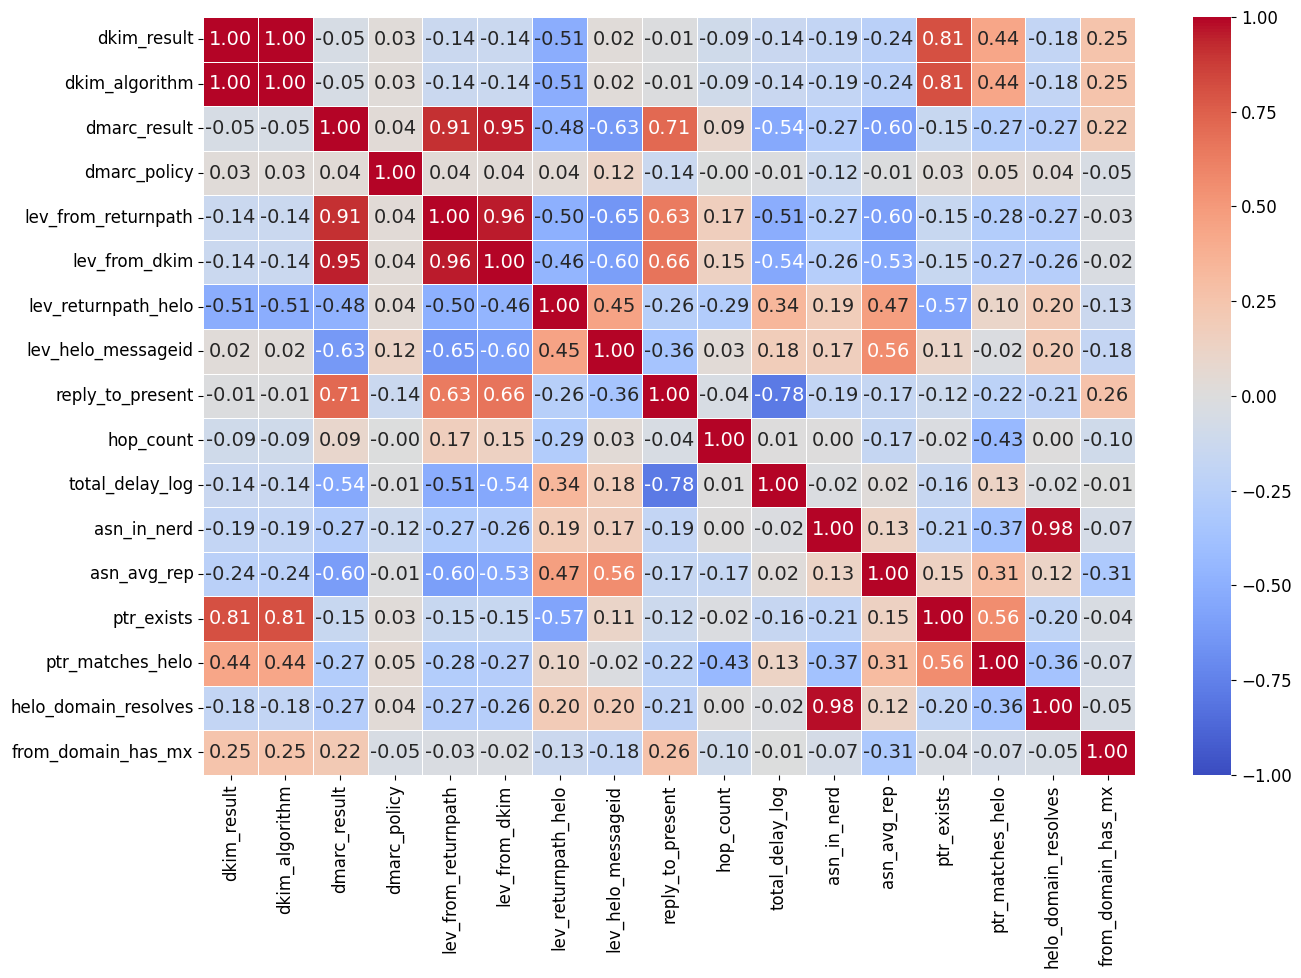

In [22]:
pearson_matrix = train_df.corr(method='pearson')

plt.figure(figsize=(14, 10))
sns.heatmap(
    pearson_matrix,
    annot=True,       
    fmt=".2f",    
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5   
)
plt.tight_layout()
plt.show()

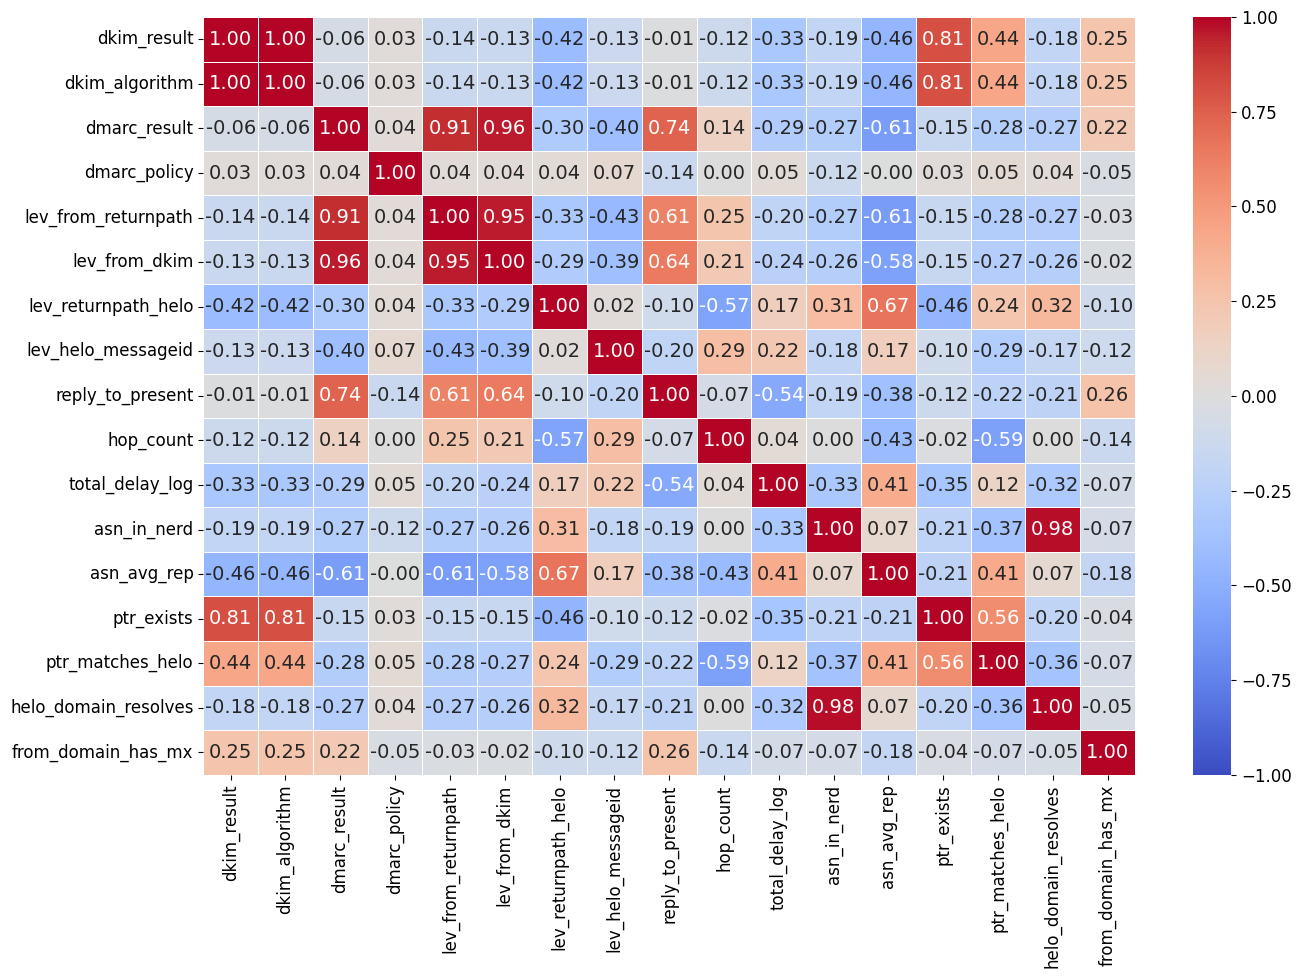

In [23]:
pearson_matrix = train_df.corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(
    pearson_matrix,
    annot=True,       
    fmt=".2f",    
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5   
)
plt.tight_layout()
plt.show()

Kaiser Rule: 7 components retained (eigenvalue > 1.0)
Cumulative variance explained: 92.5%


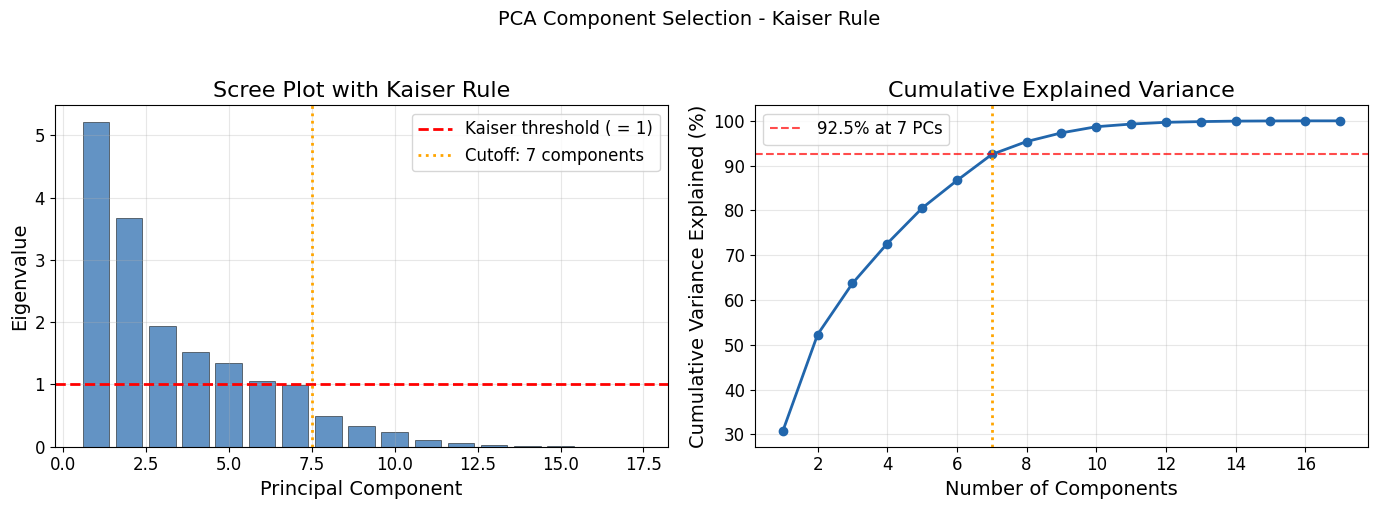


PC    Eigenvalue   Var %      Cumul %    Keep? 
---------------------------------------------
PC1   5.2194       30.69      30.69      y
PC2   3.6719       21.59      52.28      y
PC3   1.9430       11.42      63.70      y
PC4   1.5146       8.91       72.61      y
PC5   1.3446       7.91       80.51      y
PC6   1.0489       6.17       86.68      y
PC7   0.9902       5.82       92.50      
PC8   0.4894       2.88       95.38      
PC9   0.3298       1.94       97.32      
PC10  0.2337       1.37       98.69      
PC11  0.1008       0.59       99.28      
PC12  0.0665       0.39       99.67      
PC13  0.0273       0.16       99.83      
PC14  0.0181       0.11       99.94      
PC15  0.0065       0.04       99.98      
PC16  0.0035       0.02       100.00     
PC17  0.0000       0.00       100.00     


In [24]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train)
eigenvalues = pca_full.explained_variance_
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_kaiser = int(np.sum(eigenvalues > 0.9))


print(f"Kaiser Rule: {n_kaiser} components retained (eigenvalue > 1.0)")
print(f"Cumulative variance explained: {cumulative_var[n_kaiser-1]*100:.1f}%")




fig, axes = plt.subplots(1, 2, figsize=(14, 5))




axes[0].bar(range(1, len(eigenvalues)+1), eigenvalues,

            color='#2166ac', alpha=0.7, edgecolor='k', linewidth=0.5)

axes[0].axhline(y=1.0, color='red', linestyle='--', linewidth=2,

                label='Kaiser threshold ( = 1)')

axes[0].axvline(x=n_kaiser + 0.5, color='orange', linestyle=':',

                linewidth=2, label=f'Cutoff: {n_kaiser} components')

axes[0].set_xlabel('Principal Component')

axes[0].set_ylabel('Eigenvalue')

axes[0].set_title('Scree Plot with Kaiser Rule')

axes[0].legend()

axes[0].grid(True, alpha=0.3)



axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var * 100,

             'o-', color='#2166ac', linewidth=2)

axes[1].axhline(y=cumulative_var[n_kaiser-1]*100, color='red',

                linestyle='--', alpha=0.7,

                 label=f'{cumulative_var[n_kaiser-1]*100:.1f}% at {n_kaiser} PCs')

axes[1].axvline(x=n_kaiser, color='orange', linestyle=':', linewidth=2)

axes[1].set_xlabel('Number of Components')

axes[1].set_ylabel('Cumulative Variance Explained (%)')

axes[1].set_title('Cumulative Explained Variance')

axes[1].legend()

axes[1].grid(True, alpha=0.3)



plt.suptitle('PCA Component Selection - Kaiser Rule', fontsize=14, y=1.02)

plt.tight_layout()

plt.show()




print(f"\n{'PC':<5} {'Eigenvalue':<12} {'Var %':<10} {'Cumul %':<10} {'Keep?':<6}")

print("-" * 45)

for i in range(len(eigenvalues)):

    keep = "y" if eigenvalues[i] > 1.0 else ""

    print(f"PC{i+1:<3} {eigenvalues[i]:<12.4f} "

          f"{pca_full.explained_variance_ratio_[i]*100:<10.2f} "

          f"{cumulative_var[i]*100:<10.2f} {keep}")

In [25]:
pca = PCA(n_components=n_kaiser, random_state=42)

X_train_shap = X_train.copy()
X_train = pca.fit_transform(X_train)
X_test  = pca.transform(X_test)
X_val  = pca.transform(X_val)



print(f"\nPCA applied: {no_features} features -> {n_kaiser} components")
print(f"Variance retained: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"X_train shape: {X_train.shape}")


PCA applied: 17 features -> 7 components
Variance retained: 92.5%
X_train shape: (2066, 7)


In [26]:
X_val_legit = X_val[y_val == 0]
X_val_scam  = X_val[y_val == 1]

X_test_legit = X_test[y_test == 0]
X_test_scam  = X_test[y_test == 1]

In [27]:

def f1_optimal_threshold(scores, y_true, n_thresholds=500):
    thresholds = np.linspace(scores.min(), scores.max(), n_thresholds)
    best_f1 = -1
    best_thr = None

    for thr in thresholds:
        preds = (scores > thr).astype(int)
        tp = ((preds == 1) & (y_true == 1)).sum()
        fp = ((preds == 1) & (y_true == 0)).sum()
        fn = ((preds == 0) & (y_true == 1)).sum()
        p  = tp / (tp + fp) if (tp + fp) else 0
        r  = tp / (tp + fn) if (tp + fn) else 0
        f1 = 2 * p * r / (p + r) if (p + r) else 0
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr, best_f1


t_fixed = 100
sample_sizes = [32, 64, 128, 256]
rows_psi = []

for psi in sample_sizes:
    if psi > X_train.shape[0]:
        continue

    m = IsolationForest(n_estimators=t_fixed, max_samples=psi, random_state=42, contamination='auto')
    m.fit(X_train)
    sc = get_anomaly_scores(m, X_val)

    fpr_vals, tpr_vals, _ = roc_curve(y_val, sc)
    roc_auc = auc(fpr_vals, tpr_vals)

    rows_psi.append(dict(psi=psi, VAL_ROC_AUC=roc_auc))
    print(f"psi = {psi:3d} | ROC-AUC = {roc_auc:.4f}")

df_psi = pd.DataFrame(rows_psi)
best_psi = int(df_psi.loc[df_psi.VAL_ROC_AUC.idxmax(), 'psi'])
print(f"\nBest psi (ROC-AUC): {best_psi}\n")


tree_counts = [50, 75, 100, 150, 200]
rows_t = []

for t_val in tree_counts:
    m = IsolationForest(n_estimators=t_val, max_samples=best_psi, random_state=42, contamination='auto')
    m.fit(X_train)
    sc = get_anomaly_scores(m, X_val)

    fpr_vals, tpr_vals, _ = roc_curve(y_val, sc)
    roc_auc = auc(fpr_vals, tpr_vals)

    rows_t.append(dict(t=t_val, VAL_ROC_AUC=roc_auc))
    print(f"t ={t_val:4d} | ROC-AUC = {roc_auc:.4f}")

df_t = pd.DataFrame(rows_t)
best_t = int(df_t.loc[df_t.VAL_ROC_AUC.idxmax(), 't'])
print(f"\nBest t (ROC-AUC): {best_t}\n")



if_final = IsolationForest(n_estimators=best_t, max_samples=best_psi, random_state=42, contamination='auto')
if_final.fit(X_train)
sc_val_final = get_anomaly_scores(if_final, X_val)

final_threshold, final_f1 = f1_optimal_threshold(sc_val_final, y_val)

print(f"Hyperparameter tuning:")
print(f"psi = {best_psi} | t = {best_t}")
print(f"Threshold: {final_threshold:.6f}")

psi =  32 | ROC-AUC = 0.9827
psi =  64 | ROC-AUC = 0.9828
psi = 128 | ROC-AUC = 0.9844
psi = 256 | ROC-AUC = 0.9857

Best psi (ROC-AUC): 256

t =  50 | ROC-AUC = 0.9904
t =  75 | ROC-AUC = 0.9893
t = 100 | ROC-AUC = 0.9857
t = 150 | ROC-AUC = 0.9893
t = 200 | ROC-AUC = 0.9883

Best t (ROC-AUC): 50

Hyperparameter tuning:
psi = 256 | t = 50
Threshold: 0.592517


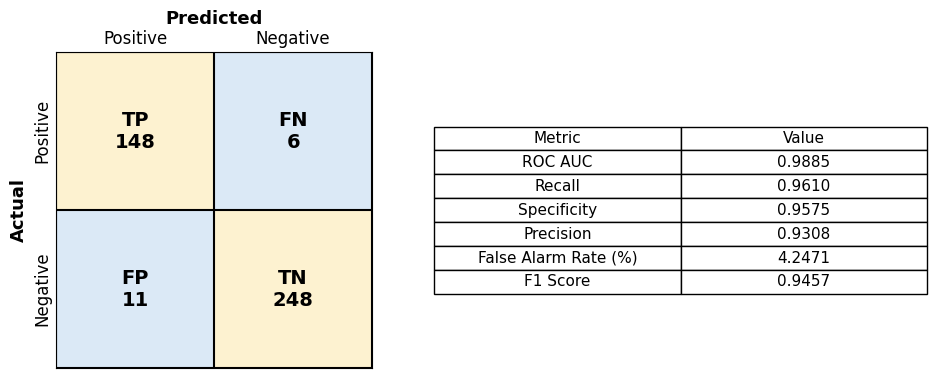

In [28]:
scores_test = get_anomaly_scores(if_final, X_test) 
scores_legit = scores_test[y_test == 0] 
scores_scam = scores_test[y_test == 1] 
scores_train = get_anomaly_scores(if_final, X_train) 

pl_legit = path_lengths(if_final, X_test_legit) 
pl_scam = path_lengths(if_final, X_test_scam) 
pl_train = path_lengths(if_final, X_train) 
preds_final = (scores_test > final_threshold).astype(int) 

tp = ((preds_final==1)&(y_test==1)).sum() 
fp = ((preds_final==1)&(y_test==0)).sum() 
tn = ((preds_final==0)&(y_test==0)).sum() 
fn = ((preds_final==0)&(y_test==1)).sum() 

roc_auc = roc_auc_score(y_test, scores_test) 
recall = tp/(tp+fn) if (tp+fn) else 0 
specificity = tn/(tn+fp) if (tn+fp) else 0 
far = fp/(fp+tn) if (fp+tn) else 0 
precision = tp/(tp+fp) if (tp+fp) else 0 
f1 = 2*precision*recall/(precision+recall) if (precision+recall) else 0

fig, (ax1, ax2) = plt.subplots( 1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1.2, 1]} )
cmap = mcolors.ListedColormap(['#dbe9f6', '#fdf2d0'])

ax1.imshow([[1, 0], [0, 1]], cmap=cmap, aspect='equal')

ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])

ax1.set_xticklabels(['Positive', 'Negative'], fontsize=12)
ax1.set_yticklabels(['Positive', 'Negative'], fontsize=12, rotation=90, va="center")

ax1.xaxis.set_label_position('top')
ax1.xaxis.tick_top()
ax1.set_xlabel('Predicted', fontsize=13, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=13, fontweight='bold')

labels = [["TP", "FN"],
          ["FP", "TN"]]

cm = np.array([[tp, fn],
               [fp, tn]])

for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{labels[i][j]}\n{cm[i, j]}",
                 ha="center", va="center",
                 fontsize=14, fontweight='bold')

ax1.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax1.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax1.grid(which='minor', color='black', linewidth=1.5)
ax1.tick_params(which='both', length=0)


df_metrics = pd.DataFrame({
    "Metric": [
        "ROC AUC",
        "Recall",
        "Specificity",
        "Precision",
        "False Alarm Rate (%)",
        "F1 Score"
    ],
    "Value": [
        roc_auc,
        recall,
        specificity,
        precision,
        far * 100,
        f1
    ]
})

df_metrics["Value"] = df_metrics["Value"].map(lambda x: f"{x:.4f}")

ax2.axis("off")

table = ax2.table(
    cellText=df_metrics.values,
    colLabels=df_metrics.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.4)

plt.tight_layout()
plt.show()

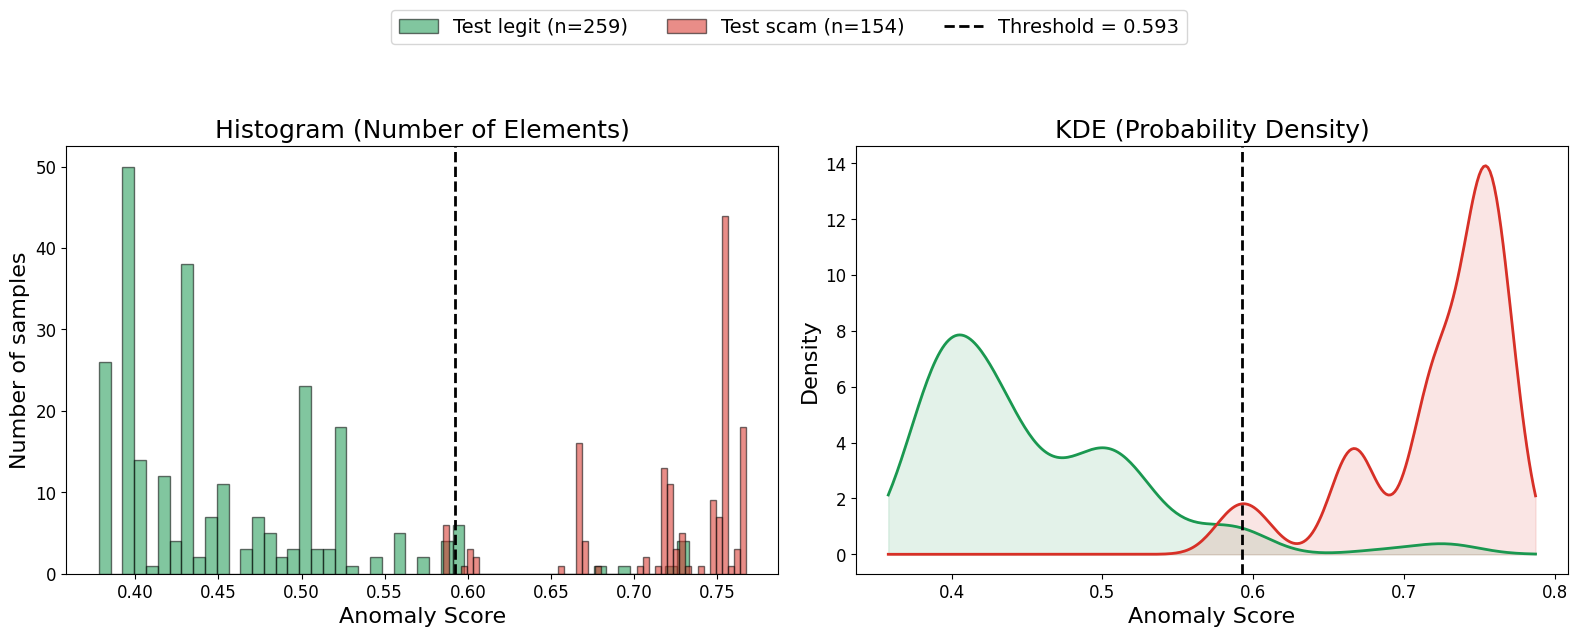

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for ax, mode in [(axes[0], 'hist'), (axes[1], 'kde')]:

    if mode == 'hist':

        # ax.hist(
        #     scores_train,
        #     bins=50,
        #     alpha=.55,
        #     density=False,
        #     color='#2166ac',
        #     edgecolor='k',
        #     lw=.3,
        #     label=f'Train legit (n={len(scores_train)})'
        # )

        ax.hist(
            scores_legit,
            bins=50,
            alpha=.55,
            density=False,
            color='#1a9850',
            edgecolor='k',
            lw=.3,
            label=f'Test legit (n={len(scores_legit)})'
        )

        ax.hist(
            scores_scam,
            bins=50,
            alpha=.55,
            density=False,
            color='#d73027',
            edgecolor='k',
            lw=.3,
            label=f'Test scam (n={len(scores_scam)})'
        )

        ax.set_title('Histogram (Number of Elements)', fontsize=18)
        ax.set_ylabel('Number of samples', fontsize=16)

    else:

        lo = min(scores_train.min(),
                 scores_legit.min(),
                 scores_scam.min()) - .02

        hi = max(scores_train.max(),
                 scores_legit.max(),
                 scores_scam.max()) + .02

        xs = np.linspace(lo, hi, 300)

        for d, lb, c in [
            # (scores_train, 'Train legit', '#2166ac'),
            (scores_legit, 'Test legit', '#1a9850'),
            (scores_scam,  'Test scam',  '#d73027')
        ]:
            k = gaussian_kde(d, bw_method=.3)
            ax.plot(xs, k(xs), lw=2, c=c, label=lb)
            ax.fill_between(xs, k(xs), alpha=.12, color=c)

        ax.set_title('KDE (Probability Density)', fontsize=18)
        ax.set_ylabel('Density', fontsize=16)
    ax.axvline(
        final_threshold,
        color='k',
        ls='--',
        lw=2,
        label=f'Threshold = {final_threshold:.3f}'
    )

    ax.set_xlabel('Anomaly Score', fontsize=16)
    # ax.legend(fontsize=14)
    # ax.grid(True, alpha=.3)


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=3,
    fontsize=14,
    bbox_to_anchor=(0.5, 1.08)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.tight_layout()
plt.show()

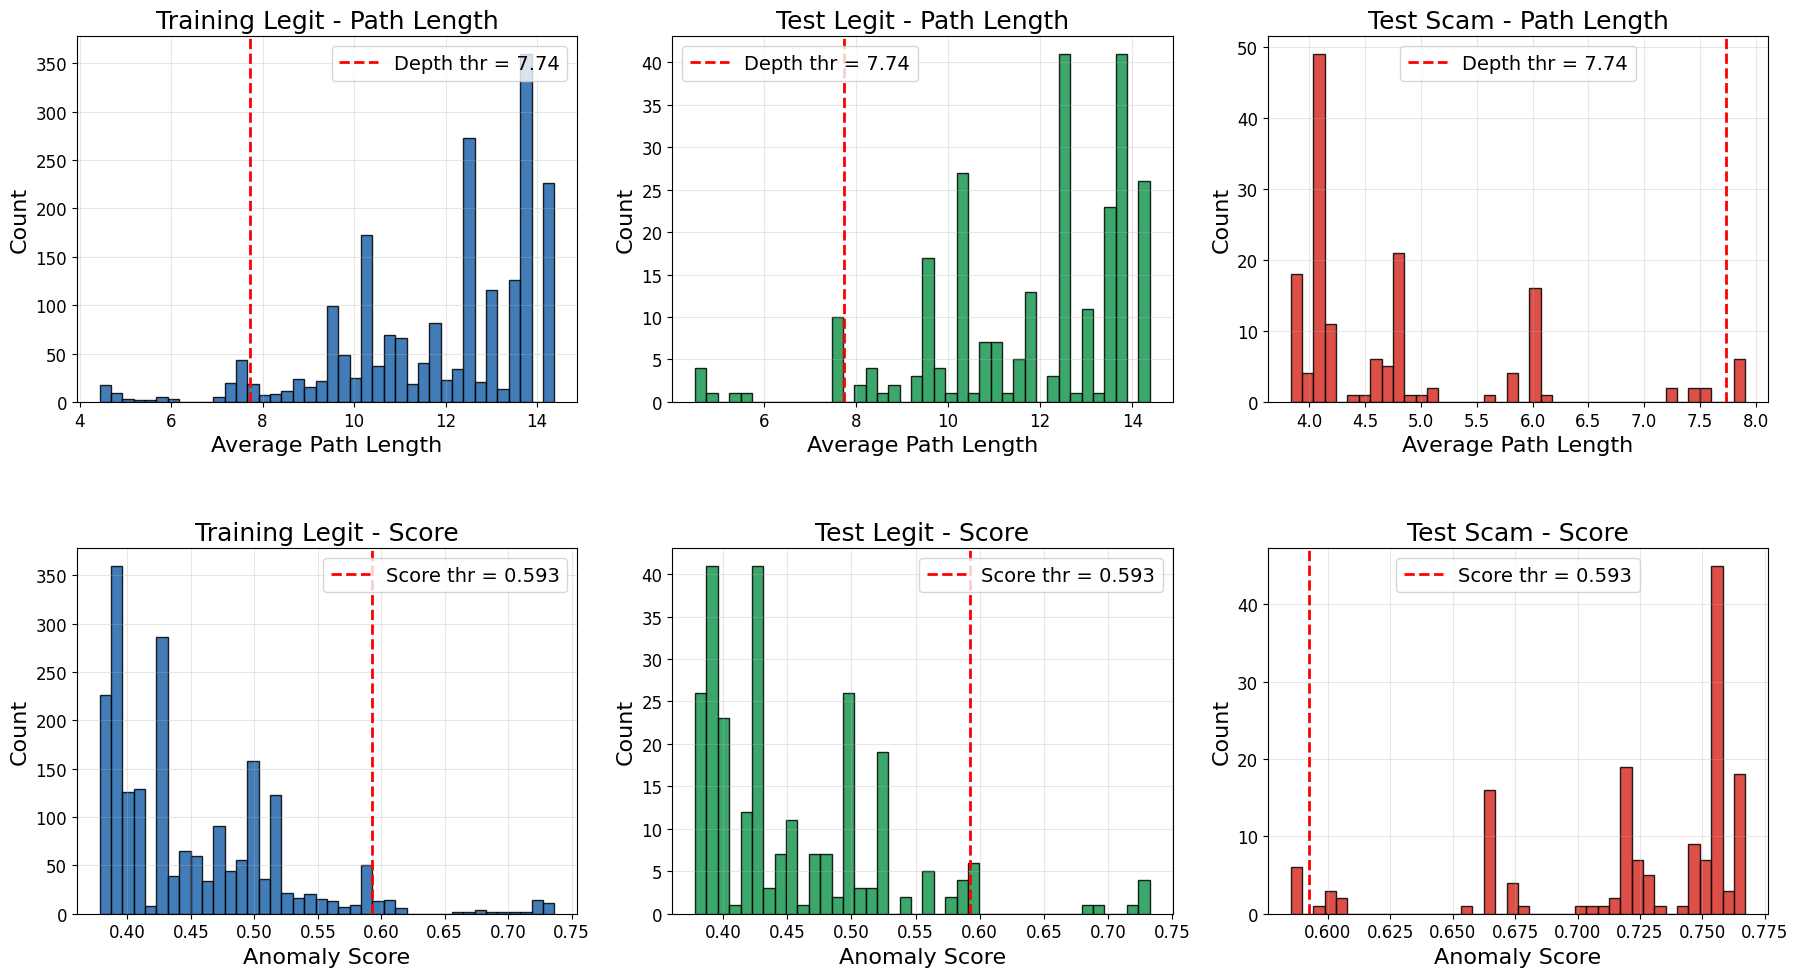

In [30]:
c_psi = c_factor(best_psi)
thr_depth = -c_psi * np.log2(final_threshold)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

datasets = [
    (pl_train, scores_train, 'Training Legit', '#2166ac'),
    (pl_legit, scores_legit, 'Test Legit', '#1a9850'),
    (pl_scam, scores_scam, 'Test Scam', '#d73027')
]

for col, (pl, sc, lbl, clr) in enumerate(datasets):

    ax = axes[0, col]
    ax.hist(pl, bins=40, color=clr, alpha=.85, edgecolor='k', lw=.3)

    ax.axvline(
        thr_depth, color='red', ls='--', lw=2,
        label=f'Depth thr = {thr_depth:.2f}'
    )

    ax.set_title(f'{lbl} - Path Length', fontsize=18)
    ax.set_xlabel('Average Path Length', fontsize=16)
    ax.set_ylabel('Count', fontsize=16)

    ax.legend(fontsize=14)
    ax.grid(True, alpha=.3)

    ax = axes[1, col]
    ax.hist(sc, bins=40, color=clr, alpha=.85, edgecolor='k', lw=.3)

    ax.axvline(
        final_threshold, color='red', ls='--', lw=2,
        label=f'Score thr = {final_threshold:.3f}'
    )

    ax.set_title(f'{lbl} - Score', fontsize=18)
    ax.set_xlabel('Anomaly Score', fontsize=16)
    ax.set_ylabel('Count', fontsize=16)

    ax.legend(fontsize=14)
    ax.grid(True, alpha=.3)

# plt.suptitle('Path Lengths and Scores (Test Set)',
#              fontsize=14, y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4) 
plt.show()

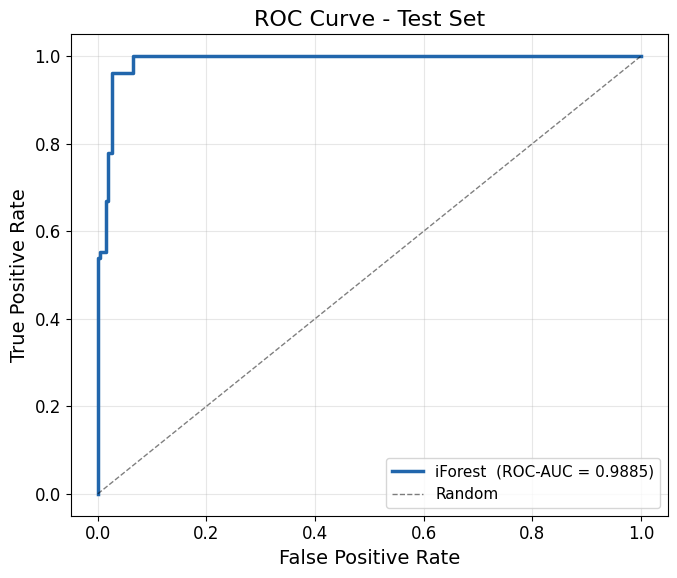

In [31]:
fpr, tpr, _ = roc_curve(y_test, scores_test)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, lw=2.5, color='#2166ac', label=f'iForest  (ROC-AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=.5, label='Random')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve - Test Set')
ax.legend(fontsize=11); ax.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

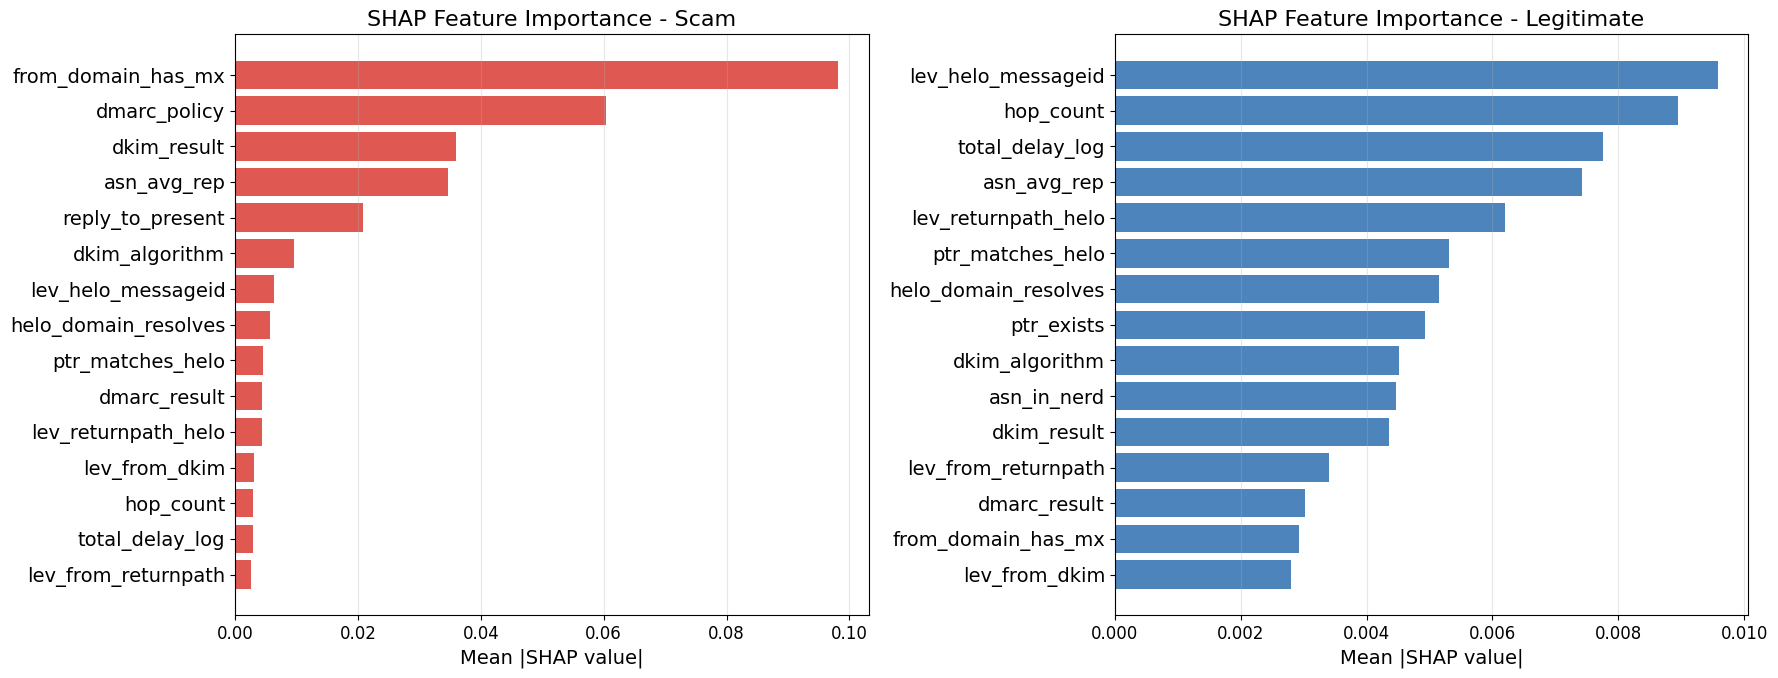

In [32]:
def predict_from_original(X_orig):
    X_pca = pca.transform(X_orig)
    return get_anomaly_scores(if_final, X_pca)

bg_idx = np.random.default_rng(42).choice(X_train_shap.shape[0], 50, replace=False)
explainer = shap.KernelExplainer(predict_from_original, X_train_shap[bg_idx])

n_ex = min(50, len(X_scam_test), len(X_ham_test))
scam_idx  = np.random.default_rng(42).choice(len(X_scam_test),  n_ex, replace=False)
legit_idx = np.random.default_rng(42).choice(len(X_ham_test), n_ex, replace=False)

sv_scam  = explainer.shap_values(X_scam_test[scam_idx],  nsamples=80, silent=True)
sv_legit = explainer.shap_values(X_ham_test[legit_idx], nsamples=80, silent=True)

plt.rcParams.update({
    'font.size': 14,          # font general
    'axes.titlesize': 16,     # titluri axe
    'axes.labelsize': 14,     # xlabel/ylabel
    'xtick.labelsize': 12,    # tick x
    'ytick.labelsize': 12,    # tick y
    'legend.fontsize': 12
})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, sv, title, clr in [
    (axes[0], sv_scam,  'Scam',       '#d73027'),
    (axes[1], sv_legit, 'Legitimate', '#2166ac')
]:
    mi = np.abs(sv).mean(0)
    si = np.argsort(mi)[::-1][:15]
    ax.barh(range(len(si)), mi[si][::-1], color=clr, alpha=.8)
    ax.set_yticks(range(len(si)))
    ax.set_yticklabels([features[i] for i in si][::-1], fontsize=14)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'SHAP Feature Importance - {title}')
    ax.grid(True, alpha=.3, axis='x')

# plt.suptitle('SHAP Analysis - IForest', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()